# M2.Ex1: Advertising Revenue

### Name: Shaima Alqahtani

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [31]:
import pandas as pd
import sklearn

## Advertising Dataset

The Advertising Dataset is a fundamental resource in statistical learning and regression analysis. It is primarily known for its use in the first chapter of the seminal textbook "An Introduction to Statistical Learning" (ISLR) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani.

The dataset is used to illustrate the relationship between advertising budgets across different media and the resulting product sales.

- Features: `3` numerical
- Target: `sales` of the product (in thousands of units).
- Size: `200` samples.
- Source: [Advertising Dataset](https://www.statlearning.com/s/Advertising.csv)

### Step 1. Load the data

In [32]:
df = pd.read_csv("../../../datasets/advertising.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


### Step 2.a Assign variables `X` to the features and `y` to the target

In [33]:
X = df[["TV", "Radio", "Newspaper"]] 
y = df["Sales"]                       

### Step 2.b print the type of each

In [34]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [35]:
print("Target type: numerical (continuous)")
print("Task type: regression")

Target type: numerical (continuous)
Task type: regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [36]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 3)
y shape: (200,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [37]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


### Step 5. How much difference do you see in the scale of each feature? (calculate the featre-wise range differences)

In [38]:
ranges = df[["TV", "Radio", "Newspaper"]].max() - df[["TV", "Radio", "Newspaper"]].min()
print("Feature-wise ranges:")
print(ranges)

Feature-wise ranges:
TV           295.7
Radio         49.6
Newspaper    113.7
dtype: float64


### Step 6.a Plot each of the features vs the target

Hint use this: `sns.pairplot()`

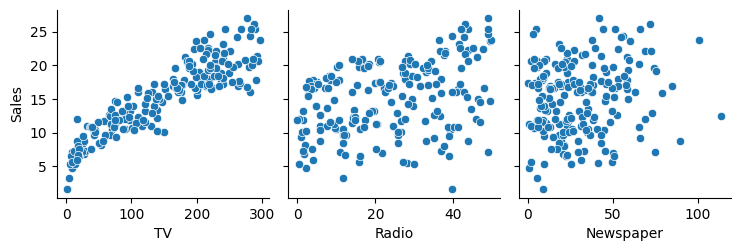

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, x_vars=["TV", "Radio", "Newspaper"], y_vars="Sales", kind="scatter")
plt.show()

### Step 6.b What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=TV` and `y=Sales`
2. `x=Radio` and `y=Sales`
3. `x=Newspaper` and `y=Sales`

In [40]:
print("TV vs Sales: increasing relationship (strong positive).")
print("Radio vs Sales: increasing relationship (moderate positive).")
print("Newspaper vs Sales: weak or no clear relationship.")

TV vs Sales: increasing relationship (strong positive).
Radio vs Sales: increasing relationship (moderate positive).
Newspaper vs Sales: weak or no clear relationship.


### Step 7. Define the pipeline with pre-processing steps

Make a Pipeline of three sequential steps:

1. transformer: `SimpleImputer` (to fill in missing values)
2. transformer: `StandardScaler` (to scale numerical features)
3. predictor: `LinearRegression` (to model the relationship)

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

predictor = LinearRegression()

pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)


### Step 9.a Fit the pipeline on the training set

In [43]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [44]:
coefs = pipe.named_steps["regressor"].coef_
intercept = pipe.named_steps["regressor"].intercept_

feature_names = X.columns

print("Coefficients:")
for name, c in zip(feature_names, coefs):
    print(f"{name}: {c:.4f}")

print(f"\nIntercept (bias): {intercept:.4f}")


Coefficients:
TV: 4.5872
Radio: 1.4898
Newspaper: 0.0879

Intercept (bias): 15.3306


### Step 9.c how much spending on TV `$1,000` more, factor into Sales?

In [45]:
sample = X_train.mean().to_frame().T  

pred_original = pipe.predict(sample)[0]

sample_tv_plus = sample.copy()
sample_tv_plus["TV"] += 1

pred_tv_plus = pipe.predict(sample_tv_plus)[0]

delta_sales_tv = pred_tv_plus - pred_original

print(f"Approximate effect of +$1,000 on TV: {delta_sales_tv:.3f} thousand units of Sales")


Approximate effect of +$1,000 on TV: 0.055 thousand units of Sales


### Step 9.d if we take `$5,000` away from Newspaper and put it in Radio how much difference does that make into Sales?

In [46]:
sample = X_train.mean().to_frame().T

pred_original = pipe.predict(sample)[0]

sample_shift = sample.copy()
sample_shift["Radio"] += 5
sample_shift["Newspaper"] -= 5

pred_shift = pipe.predict(sample_shift)[0]

delta_sales_shift = pred_shift - pred_original

print(f"Effect of moving $5,000 from Newspaper to Radio: {delta_sales_shift:.3f} thousand units of Sales")


Effect of moving $5,000 from Newspaper to Radio: 0.483 thousand units of Sales


### Step 9.e if we spend nothing at all on advertising, how much do we estimate our Sales to be?

In [47]:
zero_spend = pd.DataFrame([[0, 0, 0]], columns=["TV", "Radio", "Newspaper"])
pred_zero = pipe.predict(zero_spend)[0]

print(f"Estimated Sales with no advertising at all: {pred_zero:.3f} thousand units")

Estimated Sales with no advertising at all: 4.714 thousand units


### Step 10. Evaluate the pipeline on the test set

In [48]:
score = pipe.score(X_test, y_test)

print(f"Pipeline R^2 on test set: {score:.4f}")

Pipeline R^2 on test set: 0.9059


### Step 11. Define a `LinearRegression` model without the pre-processing steps, and compare it's score with the pipeline. Which one is better?

In [ ]:
lin_plain = LinearRegression()
lin_plain.fit(X_train, y_train)

score_plain = lin_plain.score(X_test, y_test)

print(f"Plain LinearRegression R^2 on test set: {score_plain:.4f}")
print(f"Pipeline R^2 on test set: {score:.4f}")

if score > score_plain:
    print("The pipeline with preprocessing performs better.")
elif score_plain > score:
    print("The plain LinearRegression performs better.")
else:
    print("Both models perform equally well.")


Plain LinearRegression R^2 on test set: 0.9059
Pipeline R^2 on test set: 0.9059
Both models perform equally well.
